In [17]:
import pandas as pd
import numpy as np

df = pd.read_csv(r'C:\Users\Usuario\OneDrive\football-analytics-research\data\processed\eventing-alaves_espanyol.csv')

C:\Users\Usuario\AppData\Local\Temp\ipykernel_22900\713528606.py:4: DtypeWarning: Columns (0: value_Players caught offside, 1: value_Kick Off, 2: value_Injury, 3: value_Injured player id, 4: value_Resume, 5: value_Direction of play) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'C:\Users\Usuario\OneDrive\football-analytics-research\data\processed\eventing-alaves_espanyol.csv')


In [18]:
def classify_possession_sequences(df):
    """
    Clasifica las secuencias de posesión en un dataset de eventing de fútbol.
    
    Parameters:
    df (pandas.DataFrame): DataFrame con los datos de eventing que debe contener las columnas:
                          - type: tipo de evento
                          - outcomeType: resultado del evento
                          - teamId: ID del equipo
                          - h_a: indicador de equipo local/visitante ('home'/'away')
    
    Returns:
    pandas.DataFrame: DataFrame original con columnas adicionales:
                     - sequence_id: ID único de la secuencia
                     - sequence_start: boolean indicando si es inicio de secuencia
                     - sequence_end: boolean indicando si es fin de secuencia
                     - sequence_event_number: número del evento dentro de la secuencia
    """
    
    # Crear una copia del dataframe para no modificar el original
    df_result = df.copy()
    
    # Inicializar columnas de resultado
    df_result['sequence_id'] = None
    df_result['sequence_start'] = False
    df_result['sequence_end'] = False
    df_result['sequence_event_number'] = 0
    
    # Contadores para IDs de secuencia por equipo
    sequence_counters = {'home': 0, 'away': 0}
    
    # Variables de estado
    current_sequence_id = None
    current_sequence_team = None
    current_event_number = 0
    in_sequence = False
    
    def is_sequence_start(row, prev_row):
        """Determina si el evento actual es inicio de secuencia"""
        
        # Criterio 1: Pass exitoso después de que el otro equipo tenía la pelota, después de Start, o después de CornerAwarded
        if (row['type'] == 'Pass' and row['outcomeType'] == 1):
            if prev_row is None:
                return True
            if prev_row['type'] == 'Start':
                return True
            if prev_row['type'] == 'CornerAwarded':
                return True
            if prev_row['teamId'] != row['teamId']:  # Cambio de equipo
                return True
        
        # Criterio 2: Tackle exitoso
        if row['type'] == 'Tackle' and row['outcomeType'] == 1:
            return True
            
        # Criterio 3: BlockedPass exitoso
        if row['type'] == 'BlockedPass' and row['outcomeType'] == 1:
            return True
            
        if row['type'] == 'BallRecovery' and row['outcomeType'] == 1:
            if prev_row is not None and prev_row['teamId'] != row['teamId']:
                return True   
        # Criterio 5: Interception exitoso
        if row['type'] == 'Interception' and row['outcomeType'] == 1:
            return True
            
        # Criterio 6: Claim exitoso
        if row['type'] == 'Claim' and row['outcomeType'] == 1:
            return True
            
        # Criterio 7: KeeperPickup exitoso
        if row['type'] == 'KeeperPickup' and row['outcomeType'] == 1:
            return True
            
        # Criterio especial: SavedShot después de acción del rival → inicio de secuencia
        if row['type'] == 'SavedShot':
            if prev_row is not None and prev_row['teamId'] != row['teamId'] and prev_row['type'] != 'Aerial':
                return True
            
        # Criterio especial: Goal como inicio si viene después de otro equipo
        if row['type'] == 'Goal':
            if prev_row is None or prev_row['teamId'] != row['teamId'] and prev_row['type'] != 'Aerial':
                return True
        
        return False
    
    def is_sequence_end(row, next_row=None):
        """Determina si el evento actual es fin de secuencia"""
        
        # Criterio 1: Pass no exitoso
        if row['type'] == 'Pass' and row['outcomeType'] == 0:
            return True
            
        # Criterio 2: Dispossessed exitoso
        if row['type'] == 'Dispossessed' and row['outcomeType'] == 1:
            return True
            
        # Criterio 3: BallTouch no exitoso
        if row['type'] == 'BallTouch' and row['outcomeType'] == 0:
            return True
            
        # Criterio 4: OffsidePass no exitoso
        if row['type'] == 'OffsidePass':
            return True
            
        # Criterio 5: Foul exitoso
        if row['type'] == 'Foul' and row['outcomeType'] == 1:
            return True
            
        # Criterio 6: Goal
        if row['type'] == 'Goal':
            return True
            
        # Criterio 7: MissedShots
        if row['type'] == 'MissedShots':
            return True
        
        # Criterio especial: ShotOnPost seguido de cambio de equipo → fin de secuencia
        if row['type'] == 'ShotOnPost':
            if next_row is not None and next_row['teamId'] != row['teamId']:
                return True
            
        # Criterio especial: SavedShot después de acción del mismo equipo → fin de secuencia
        if row['type'] == 'SavedShot':
            if next_row is None or next_row['teamId'] != row['teamId']:  # optional for clarity
                return True
        
            # Criterio 9: TakeOn no exitoso, salvo si lo siguiente es Foul
        if row['type'] == 'TakeOn' and row['outcomeType'] == 0:
            if next_row is not None and next_row['type'] == 'Foul':
                return False  # no termina la secuencia porque fue falta después del intento
            return True
        
        # If next event is a meta/informational event → end current sequence
        if next_row is not None and next_row['type'] in ['FormationChange', 'SubstitutionOn', 'SubstitutionOff', 'End']:
            return True
            
        return False
    
    # Procesar cada fila del dataframe
    for idx, row in df_result.iterrows():
        
        # Obtener la fila anterior
        prev_row = df_result.iloc[idx-1] if idx > 0 else None
        
        # Verificar si es inicio de secuencia
        if is_sequence_start(row, prev_row):
            # Si ya estaba en una secuencia, cerrarla primero
            if in_sequence and current_sequence_id is not None:
                # Marcar el evento anterior como fin de secuencia
                if idx > 0:
                    df_result.iloc[idx-1, df_result.columns.get_loc('sequence_end')] = True
            
            # Iniciar nueva secuencia
            team = row['h_a']
            sequence_counters[team] += 1
            current_sequence_id = f"{team}_{sequence_counters[team]:03d}"
            current_sequence_team = team
            current_event_number = 1
            in_sequence = True
            
            # Marcar como inicio de secuencia
            df_result.iloc[idx, df_result.columns.get_loc('sequence_start')] = True
        
        # Si estamos en una secuencia, asignar el ID
        if in_sequence and current_sequence_id is not None:
            # Asignar ID a todos los eventos dentro de la secuencia, independientemente del equipo
            df_result.iloc[idx, df_result.columns.get_loc('sequence_id')] = current_sequence_id
            df_result.iloc[idx, df_result.columns.get_loc('sequence_event_number')] = current_event_number
            current_event_number += 1
        
        # Verificar si es fin de secuencia
        if in_sequence and is_sequence_end(row):
            df_result.iloc[idx, df_result.columns.get_loc('sequence_end')] = True
            in_sequence = False
            current_sequence_id = None
            current_sequence_team = None
            current_event_number = 0
    
    return df_result

def get_sequence_summary(df_classified):
    """
    Genera un resumen de las secuencias clasificadas.
    
    Parameters:
    df_classified (pandas.DataFrame): DataFrame con las secuencias ya clasificadas
    
    Returns:
    pandas.DataFrame: Resumen con estadísticas de cada secuencia
    """
    
    # Filtrar solo los eventos que pertenecen a alguna secuencia
    sequences_df = df_classified[df_classified['sequence_id'].notna()].copy()
    
    if sequences_df.empty:
        return pd.DataFrame()
    
    # Agrupar por secuencia y calcular estadísticas
    summary = sequences_df.groupby('sequence_id').agg({
        'eventId': 'count',  # Número de eventos en la secuencia
        'minute': ['min', 'max'],  # Minuto de inicio y fin
        'x': ['min', 'max'],  # Rango de coordenadas X
        'y': ['min', 'max'],  # Rango de coordenadas Y
        'xT': 'sum',  # Suma del Threat total
        'h_a': 'first',  # Equipo de la secuencia
        'period': 'first'  # Período del partido
    }).round(3)
    
    # Aplanar los nombres de columnas
    summary.columns = ['num_events', 'start_minute', 'end_minute', 
                      'min_x', 'max_x', 'min_y', 'max_y', 
                      'total_xT', 'team', 'period']
    
    # Calcular duración de la secuencia
    summary['duration_minutes'] = summary['end_minute'] - summary['start_minute']
    
    # Calcular distancia recorrida (aproximada)
    summary['distance_covered'] = np.sqrt((summary['max_x'] - summary['min_x'])**2 + 
                                        (summary['max_y'] - summary['min_y'])**2)
    
    # Resetear el índice para que sequence_id sea una columna
    summary = summary.reset_index()
    
    return summary

In [19]:
# Clasificar las secuencias
df_with_sequences = classify_possession_sequences(df)

# Obtener resumen estadístico
##sequence_stats = get_sequence_summary(df_with_sequences)

In [23]:
df_with_sequences[df_with_sequences['sequence_id']== 'away_073']['player_JerseyNumber']

1989    12.0
1990     5.0
Name: player_JerseyNumber, dtype: float64

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from mplsoccer import Pitch

def plot_goal_sequence(df_sequence, sequence_id=None, figsize=(14, 9)):
    """
    Visualiza una secuencia de acciones que termina en gol en un campo de fútbol.
    
    Parameters:
    df_sequence (pandas.DataFrame): DataFrame con las acciones de la secuencia
    sequence_id (str): ID de la secuencia específica a visualizar (opcional)
    figsize (tuple): Tamaño de la figura
    
    Returns:
    fig, ax: Objetos de matplotlib para posterior manipulación
    """
    
    # Filtrar la secuencia específica si se proporciona
    if sequence_id:
        df_plot = df_sequence[df_sequence['sequence_id'] == sequence_id].copy()
    else:
        df_plot = df_sequence.copy()
    
    if df_plot.empty:
        print("No hay datos para visualizar")
        return None, None
    
    # Identificar el equipo principal de la secuencia (el que más acciones tiene)
    team_counts = df_plot['h_a'].value_counts()
    main_team = team_counts.index[0]
    
    # Filtrar solo las acciones del equipo principal
    df_plot = df_plot[df_plot['h_a'] == main_team].copy()
    
    # Crear el campo de fútbol
    pitch = Pitch(pitch_type='custom', 
                  pitch_width=68, 
                  pitch_length=105,
                  line_color='#7c7c7c', 
                  linewidth=0.5)
    
    fig, ax = pitch.draw(figsize=figsize)
    fig.patch.set_facecolor('#FFF1E0')
    ax.set_facecolor('#FFF1E0')
    
    # Filtrar solo los tipos de acciones que queremos visualizar
    actions_to_plot = ['Pass', 'Carry', 'Goal', 'MissedShots', 'SavedShot']
    df_plot = df_plot[df_plot['type'].isin(actions_to_plot)].copy()
    
    if df_plot.empty:
        print("No hay acciones del equipo principal para visualizar")
        return None, None
    
    # Color del equipo
    team_color = '#2388C4'
    
    # Identificar grupos de acciones consecutivas por jugador
    def get_player_action_groups(df):
        """
        Identifica grupos de acciones consecutivas por jugador.
        Devuelve una lista de posiciones donde cada jugador debe aparecer.
        """
        player_positions = []
        df_reset = df.reset_index(drop=True)
        
        if len(df_reset) == 0:
            return player_positions
        
        current_player = None
        group_start_idx = None
        
        for idx, row in df_reset.iterrows():
            player = row.get('player_JerseyNumber', 'N/A')
            
            if player != current_player:
                # Si cambia el jugador, guardamos la posición del grupo anterior
                if current_player is not None and group_start_idx is not None:
                    # Tomar la última acción del grupo anterior
                    last_action_idx = idx - 1
                    player_positions.append({
                        'player': current_player,
                        'position_idx': last_action_idx,
                        'x': df_reset.iloc[last_action_idx]['x'],
                        'y': df_reset.iloc[last_action_idx]['y']
                    })
                
                # Iniciar nuevo grupo
                current_player = player
                group_start_idx = idx
        
        # No olvidar el último grupo
        if current_player is not None and group_start_idx is not None:
            last_idx = len(df_reset) - 1
            player_positions.append({
                'player': current_player,
                'position_idx': last_idx,
                'x': df_reset.iloc[last_idx]['x'],
                'y': df_reset.iloc[last_idx]['y']
            })
        
        return player_positions
    
    # Obtener las posiciones donde debe aparecer cada jugador
    player_positions = get_player_action_groups(df_plot)
    
    # Identificar al jugador que termina la secuencia (última acción)
    final_player = df_plot.iloc[-1].get('player_JerseyNumber', 'N/A')
    
    # Dibujar cada acción
    for idx, row in df_plot.iterrows():
        x_start = row['x']
        y_start = row['y']
        x_end = row.get('endX', x_start)  # Si no hay endX, usar la misma coordenada
        y_end = row.get('endY', y_start)  # Si no hay endY, usar la misma coordenada
        
        action_type = row['type']
        jersey_number = row.get('player_JerseyNumber', 'N/A')
        
        # Configuración por tipo de acción
        if action_type == 'Pass':
            # Pase: línea gris completa
            ax.plot([x_start, x_end], [y_start, y_end], 
                   color='gray', linewidth=1.5, alpha=0.8)
            
            # Calcular punto medio para la flecha
            x_mid = (x_start + x_end) / 2
            y_mid = (y_start + y_end) / 2
            
            # Calcular dirección para orientar la flecha
            dx = x_end - x_start
            dy = y_end - y_start
            if dx != 0 or dy != 0:  # Evitar división por cero
                # Normalizar el vector dirección
                length = np.sqrt(dx**2 + dy**2)
                dx_norm = dx / length
                dy_norm = dy / length
                
                # Punto ligeramente adelante del medio para la flecha
                arrow_offset = 2  # Ajustar según sea necesario
                x_arrow = x_mid + dx_norm * arrow_offset
                y_arrow = y_mid + dy_norm * arrow_offset
                
                # Dibujar solo la cabeza de flecha en el punto medio (sin cuerpo)
                ax.annotate('', xy=(x_arrow, y_arrow), xytext=(x_mid, y_mid),
                           arrowprops=dict(arrowstyle='->,head_width=0.8,head_length=1.0', 
                                         color='gray', linewidth=1.5, alpha=0.8))
            
            # Punto de inicio del pase
            pitch.scatter(x_start, y_start, s=100, color='gray', alpha=0.6, 
                         edgecolors='black', linewidth=1, ax=ax, zorder=3)
            
        elif action_type == 'Carry':
            # Conducción: línea discontinua con puntos, color gris
            ax.plot([x_start, x_end], [y_start, y_end], 
                   color='gray', linestyle=':', linewidth=2, alpha=0.8, marker='.')
            
            # Puntos de inicio y fin
            pitch.scatter(x_start, y_start, s=100, color='gray', alpha=0.6,
                         edgecolors='black', linewidth=1, ax=ax, zorder=3)
            pitch.scatter(x_end, y_end, s=100, color='gray', alpha=0.6,
                         edgecolors='black', linewidth=1, ax=ax, zorder=3)
            
        elif action_type in ['Goal', 'MissedShots', 'SavedShot']:
            # Para goles, la flecha siempre termina en x=105, y=34 (centro de la portería)
            if action_type == 'Goal':
                x_end = 105
                y_end = 34
                # Para goles, flecha al final
                ax.annotate('', xy=(x_end, y_end), xytext=(x_start, y_start),
                           arrowprops=dict(arrowstyle='->,head_width=0.8,head_length=1.0', 
                                         color=team_color, lw=1.5))
            else:
                # Para tiros fallados o salvados, flecha en el medio
                # Tiro: línea azul completa
                ax.plot([x_start, x_end], [y_start, y_end], 
                       color=team_color, linewidth=1.5, alpha=0.8)
                
                # Calcular punto medio para la flecha
                x_mid = (x_start + x_end) / 2
                y_mid = (y_start + y_end) / 2
                
                # Calcular dirección para orientar la flecha
                dx = x_end - x_start
                dy = y_end - y_start
                if dx != 0 or dy != 0:  # Evitar división por cero
                    # Normalizar el vector dirección
                    length = np.sqrt(dx**2 + dy**2)
                    dx_norm = dx / length
                    dy_norm = dy / length
                    
                    # Punto ligeramente adelante del medio para la flecha
                    arrow_offset = 3  # Un poco más grande para tiros
                    x_arrow = x_mid + dx_norm * arrow_offset
                    y_arrow = y_mid + dy_norm * arrow_offset
                    
                    # Dibujar solo la cabeza de flecha en el punto medio (sin cuerpo)
                    ax.annotate('', xy=(x_arrow, y_arrow), xytext=(x_mid, y_mid),
                               arrowprops=dict(arrowstyle='->,head_width=0.8,head_length=1.0', 
                                             color=team_color, linewidth=0))
            
            # Punto de tiro
            pitch.scatter(x_start, y_start, s=400, color=team_color, alpha=0.7,
                         edgecolors=team_color, linewidth=1, marker='*', ax=ax, zorder=4)
    
    # Dibujar dorsales para cada jugador en sus posiciones correspondientes
    for pos_info in player_positions:
        x_pos = pos_info['x']
        y_pos = pos_info['y']
        jersey_number = pos_info['player']
        
        # Determinar el color del jugador
        if jersey_number == final_player:
            # Jugador que termina la acción: color azul
            face_color = team_color
            edge_color = team_color
            text_color = 'white'
        else:
            # Jugador que no termina la acción: blanco con borde azul
            face_color = 'white'
            edge_color = team_color
            text_color = team_color
        
        # Burbuja con el número del jugador
        pitch.scatter(x_pos, y_pos, s=400, color=face_color, alpha=1.0,
                     edgecolors=edge_color, linewidth=2, ax=ax, zorder=6)
        ax.text(x_pos, y_pos, f'{int(jersey_number)}', 
               fontsize=8, ha='center', va='center', weight='bold', 
               zorder=7, color=text_color)
    
    # Configuración del gráfico
    ax.set_title(f'Secuencia de Gol - {sequence_id if sequence_id else "Visualización"}', 
                fontsize=16, weight='bold', pad=20)
    
    # Crear leyenda personalizada debajo del campo
    _create_custom_legend(ax, team_color)
    
    plt.tight_layout()
    return fig, ax


def _create_custom_legend(ax, team_color):
    """
    Create a simple horizontal legend matching the provided design.
    
    Args:
        ax: Matplotlib axis
        team_color: Color of the team
    """
    # Legend position (bottom center of pitch)
    legend_y = -3
    center_x = 52.5  # Center of the pitch (105/2)
    
    # Define legend elements in horizontal layout
    legend_elements = [
        {'type': 'start_event', 'label': 'Participantes', 'color': '#2388C4'},  # Purple
        {'type': 'end_event', 'label': 'Finalización', 'color': '#2388C4'},     # Red
        {'type': 'pass', 'label': 'Pass', 'color': 'gray'},
        {'type': 'carry', 'label': 'Carry', 'color': 'gray'}
    ]
    
    # Calculate spacing
    total_elements = len(legend_elements)
    element_spacing = 15  # Distance between elements
    total_width = (total_elements - 1) * element_spacing
    start_x = center_x - (total_width / 2)
    
    # Draw each legend element
    for i, element in enumerate(legend_elements):
        x_pos = start_x + (i * element_spacing)
        
        # Draw the visual element
        if element['type'] == 'start_event':
            # Purple circle for start event
            ax.scatter(x_pos, legend_y, s=150, color='white', 
                      edgecolors=element['color'], linewidth=1, zorder=6)
            
        elif element['type'] == 'end_event':
            # Red circle for end event
            ax.scatter(x_pos, legend_y, s=150, color=element['color'], 
                      edgecolors=element['color'], linewidth=1, zorder=6)
            
        elif element['type'] == 'pass':
            # Solid line with arrow for pass
            line_start = x_pos - len('pass')
            line_end = x_pos + len('pass')
            ax.plot([line_start, line_end], [legend_y, legend_y], 
                   color=element['color'], linewidth=2)
            # Arrow at the end
            ax.annotate('', xy=(x_pos+1, legend_y), xytext=(x_pos-0.5, legend_y),
                       arrowprops=dict(arrowstyle='->,head_width=0.4,head_length=0.5', color=element['color'], 
                                     lw=2))
            
        elif element['type'] == 'carry':
            # Dotted line for carry
            line_start = x_pos - len('carry')
            line_end = x_pos + len('carry')
            ax.plot([line_start, line_end], [legend_y, legend_y], 
                   color=element['color'], linestyle=':', linewidth=2)
        
        # Add text label above the element
        ax.text(x_pos, legend_y + 1, element['label'], fontsize=10, 
               ha='center', va='bottom', color='#333333', weight='normal')
    

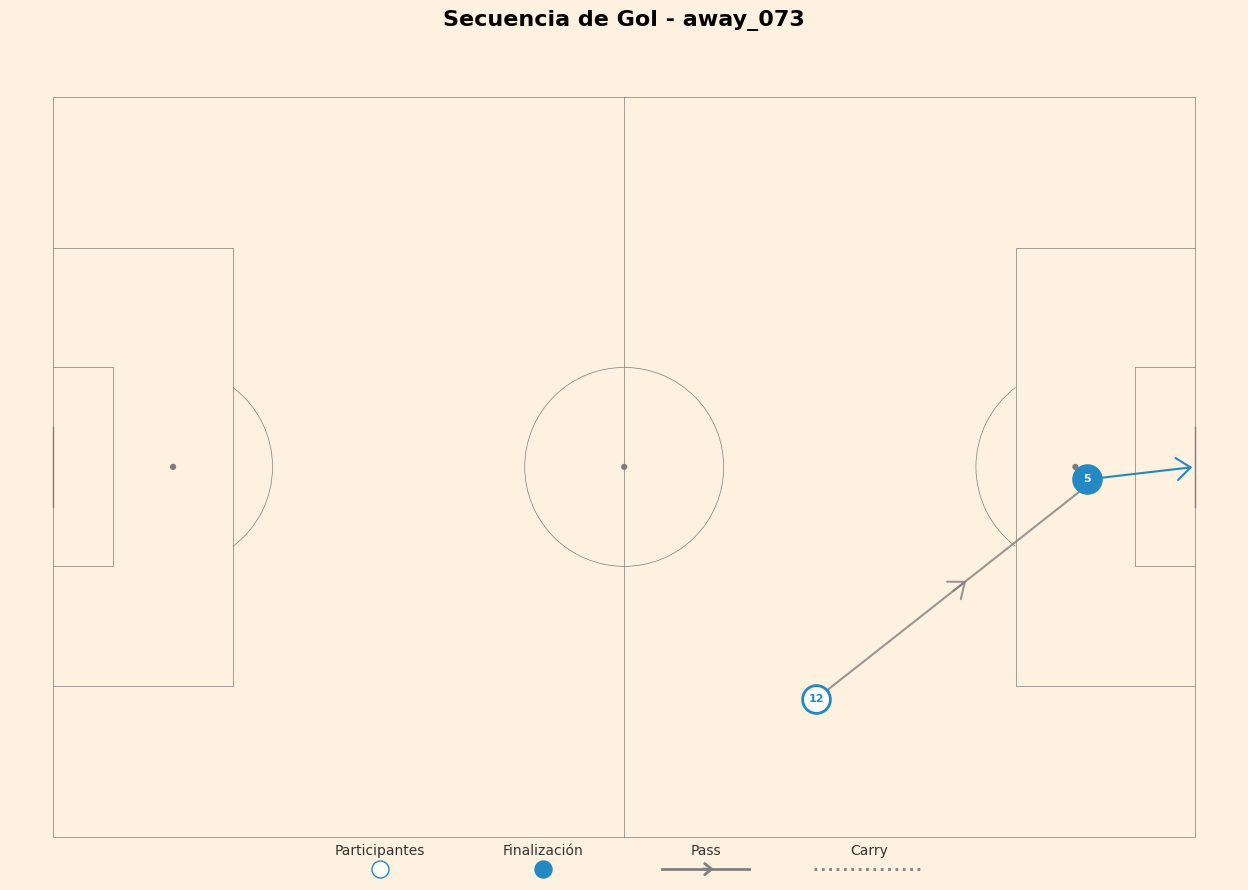

In [25]:
# Para una secuencia específica que termina en gol
fig, ax = plot_goal_sequence(df_with_sequences, sequence_id='away_073')
plt.show()